**Mini Project - House Prices - Baseline Model**

*Name: Alisha Khan ,  Batch - II, IBA*

*Course: Artificial Intelligence, Machine Learning & Data Science*

**Problem type:**

✔ Supervised Learning

✔ Regression

**PART: 01 DATA EXPLORATION**

In [ ]:
# data handling
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
train.head()  # first look

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.info()   # info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
train.describe() # summary stats

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


* The Dataset contains numerical and categorical features. Some columns have missing values. And the target variable is a Sale Price which is continuous in nature. Also the data has a wide range.

**PART: 02 DATA CLEANING**

*a) Missing Values*

In [ ]:
# checking missing values
train.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
# Fill numeric
train = train.fillna(train.median(numeric_only=True))

# Fill categorical
train = train.fillna("None")

* Missing values are handle differently based on the type of data. For numerical features, I used the median because it is less affected by extreme values and gives a more stable result. For categorical features, I replaced missing values with “None” to clearly indicate that the feature was not present rather than guessing an incorrect category.

*b) Categorical Encoding*

In [ ]:
train = pd.get_dummies(train)
test = pd.get_dummies(test)

* Categorical variables are convert into numerical format using one-hot encoding. This step is necessary because machine learning models cannot process text values directly, so encoding allows the model to understand and use this information effectively.

*c) Outliers*

<Axes: ylabel='SalePrice'>

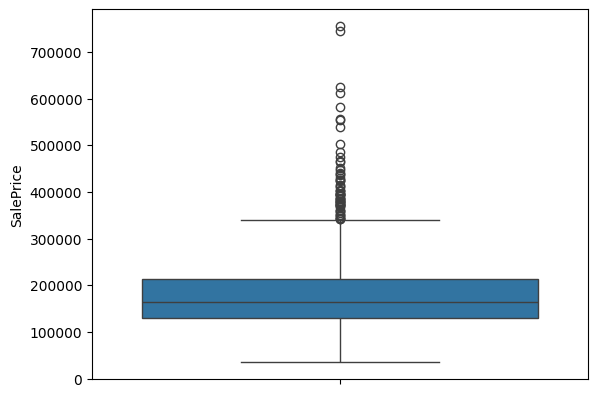

In [ ]:
import seaborn as sns

sns.boxplot(train["SalePrice"])

* Outliers are explore using boxplots to understand the distribution of the target variable. Although some extreme values are visible, they aren't remove aggressively to avoid losing potentially important information that could influence the model’s learning.

*d) Data Consistency*

In [ ]:
train.duplicated().sum()

np.int64(0)

* The dataset is check for duplicate records to ensure data quality. No significant duplicates were found, so no removal was required and the dataset remained consistent.

**Part: 03 Model Building**

*a) Train Test Split*

In [ ]:
from sklearn.model_selection import train_test_split

X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

* The dataset is divid into training and validation sets using a train-test split. This step is important to evaluate how well the model performs on unseen data. By training the model on one portion of the data and validating it on another, we can check whether the model is learning meaningful patterns or just memorizing the data.

*b) Linear Regression*

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

* A Linear Regression model is used to predict house prices. This algorithm is suitable because the target variable (SalePrice) is continuous. The model learns the relationship between input features and the target variable and uses this relationship to make predictions on new data.

*c) Evaluation*

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred_val = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred_val))
r2 = r2_score(y_val, pred_val)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 32944.57654841305
R2 Score: 0.8405007054987701


* Model performance is evaluate using RMSE and R² score. RMSE measures how far the predicted values are from the actual values, so a lower RMSE indicates better performance. R² score shows how much of the variation in the target variable is explained by the model, so a higher value means the model is performing well.

**Part: 04 Prediction**

*a) Align Columns*

In [ ]:
X, test = X.align(test, join='left', axis=1, fill_value=0)
test = test.fillna(0)

*b) Prediction*

In [ ]:
val_pred = model.predict(X_val) ## validation

In [ ]:
test_pred = model.predict(test)

* Before making final predictions, the training and test datasets are align to ensure they have the same set of features. This step is necessary after encoding, as differences in columns can cause errors during prediction. Any remaining missing values in the test dataset were handled to ensure compatibility with the model. After validating the model using the validation set, final predictions were generated on the unseen test dataset.

*c) Submission File*

In [ ]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_pred
})

submission.to_csv("submission.csv", index=False)

*Checking the result*

In [ ]:
print(test["Id"].head())

0    1461
1    1462
2    1463
3    1464
4    1465
Name: Id, dtype: int64


In [ ]:
print(len(test))

1459
